In [1]:
import xarray as xr
import numpy as np
import os
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.colors import BoundaryNorm

import scipy
from scipy.stats import ttest_ind

/home/gabriela/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/gabriela/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
os.chdir('/mnt/storage0/jmarson/NEMO/ANHA4/ANHA4-EJM009-S')

data_coord = xr.open_dataset('ANHA4-EJM009_y2002m01d05_gridT.nc')

lat = data_coord.variables['nav_lat_grid_T']
lon = data_coord.variables['nav_lon_grid_T']

In [ ]:
data_path = '/mnt/storage0/gabriela/ANALYSES/SCRIPTS/data_from_scripts/Temperature'

all_avg_vs = []
all_avg_vd = []

years = np.arange(2007, 2018)
vmin = -1
vmax = 1
levels = 50
lv = (vmax - vmin) / levels
levels = np.arange(vmin, vmax + lv, lv)
cmap = plt.get_cmap('seismic')
years = np.arange(2007, 2018)

for idx, year in enumerate(years):
    print(f"▶️ Processing {year}...")

    vs_file = f'ANHA4-EJM010-S_{year}_Temperature.npz'
    vd_file = f'ANHA4-EJM012-S_{year}_Temperature.npz'
    data_vs = np.load(os.path.join(data_path, vs_file))['DataTemp']
    data_vd = np.load(os.path.join(data_path, vd_file))['DataTemp']
    
    # From the surface to 55m deep
    avg_vs = np.nanmean(data_vs[:, 0:19], axis=1) 
    avg_vd = np.nanmean(data_vd[:, 0:19], axis=1)

    all_avg_vs.append(avg_vs)
    all_avg_vd.append(avg_vd)

In [ ]:
# Stack across time (year)
all_avg_vs = np.stack(all_avg_vs, axis=0)
all_avg_vd = np.stack(all_avg_vd, axis=0)

In [ ]:
all_avg_vs = all_avg_vs.reshape(-1, 800, 544)
all_avg_vd = all_avg_vd.reshape(-1, 800, 544)

In [ ]:
dif_upper = np.nanmean(all_avg_vd, axis=0) - np.nanmean(all_avg_vs, axis=0)
dif_upper = np.clip(dif_upper, vmin, vmax)

In [ ]:
stat_upper, p_val_upper = ttest_ind(all_avg_vd, all_avg_vs, axis=0, nan_policy='omit')

In [ ]:
data_path = '/mnt/storage0/gabriela/ANALYSES/SCRIPTS/data_from_scripts/Temperature'

all_avg_vs = []
all_avg_vd = []

years = np.arange(2007, 2018)
vmin = -1
vmax = 1
levels = 50
lv = (vmax - vmin) / levels
levels = np.arange(vmin, vmax + lv, lv)
cmap = plt.get_cmap('seismic')
years = np.arange(2007, 2018)

for idx, year in enumerate(years):
    print(f"▶️ Processando {year}...")

    vs_file = f'ANHA4-EJM010-S_{year}_Temperature.npz'
    vd_file = f'ANHA4-EJM012-S_{year}_Temperature.npz'
    data_vs = np.load(os.path.join(data_path, vs_file))['DataTemp']
    data_vd = np.load(os.path.join(data_path, vd_file))['DataTemp']
    
    # From 55m to 541m deep
    avg_vs = np.nanmean(data_vs[:, 19:31], axis=1)  
    avg_vd = np.nanmean(data_vd[:, 19:31], axis=1)

    all_avg_vs.append(avg_vs)
    all_avg_vd.append(avg_vd)

# Stack across time (year)
all_avg_vs = np.stack(all_avg_vs, axis=0)
all_avg_vd = np.stack(all_avg_vd, axis=0)

all_avg_vs = all_avg_vs.reshape(-1, 800, 544)
all_avg_vd = all_avg_vd.reshape(-1, 800, 544)

dif_lower = np.nanmean(all_avg_vd, axis=0) - np.nanmean(all_avg_vs, axis=0)
dif_lower = np.clip(dif_lower, vmin, vmax)

stat_lower, p_val_lower = ttest_ind(all_avg_vd, all_avg_vs, axis=0, nan_policy='omit')

In [ ]:
# Stack across time (year)
all_avg_vs = np.stack(all_avg_vs, axis=0)
all_avg_vd = np.stack(all_avg_vd, axis=0)

In [ ]:
all_avg_vs = all_avg_vs.reshape(-1, 800, 544)
all_avg_vd = all_avg_vd.reshape(-1, 800, 544)

In [ ]:
dif_lower = np.nanmean(all_avg_vd, axis=0) - np.nanmean(all_avg_vs, axis=0)
dif_lower = np.clip(dif_lower, vmin, vmax)

In [ ]:
stat_lower, p_val_lower = ttest_ind(all_avg_vd, all_avg_vs, axis=0, nan_policy='omit')

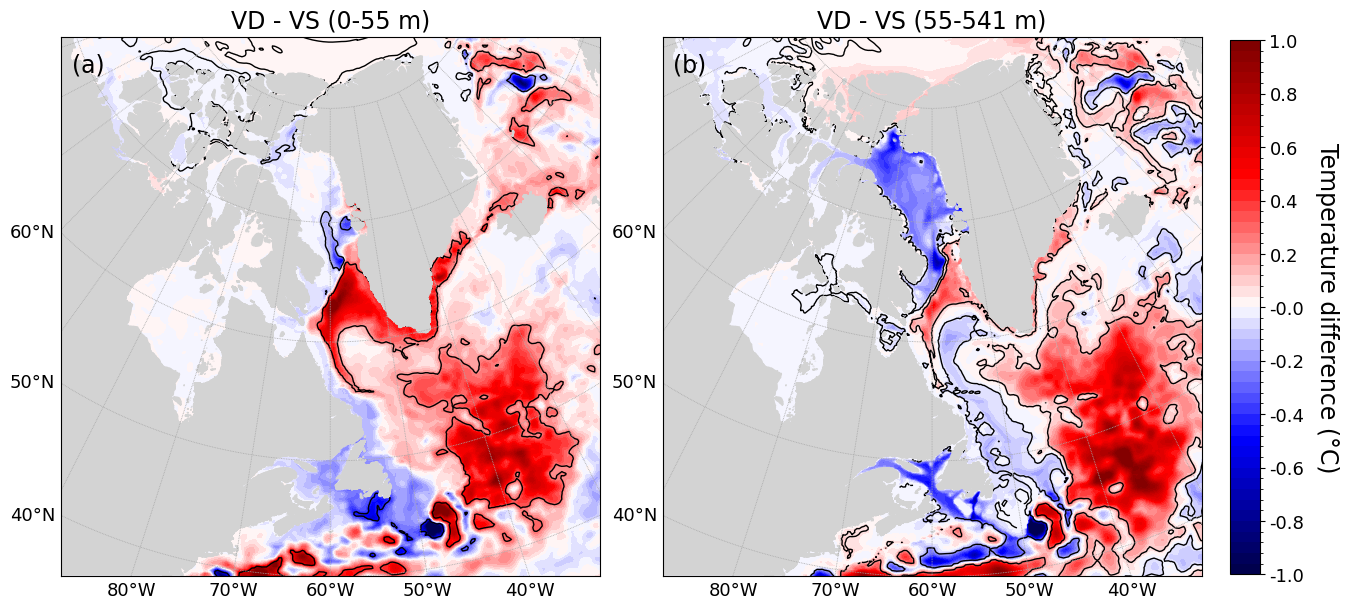

In [15]:
vmin = -1
vmax = 1
levels = 50
lv = (vmax - vmin) / levels
levels = np.arange(vmin, vmax + lv, lv)
cmap = plt.get_cmap('seismic')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

titles = ['VD - VS (0-55 m)', 'VD - VS (55-541 m)']
datasets = [dif_upper, dif_lower]
pvals = [p_val_upper, p_val_lower]

fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

for ax, data, data2, title in zip(axs, datasets, pvals, titles):
    ax.set_title(title, fontsize=17)
    
    m = Basemap(projection='aea', resolution='f', width=5E6, height=5E6, lat_0=63, lon_0=-60, ax=ax)

    m.contourf(lon, lat, data, latlon=True, levels=levels, vmin=vmin, vmax=vmax, cmap=cmap)
    cs = m.contour(lon, lat, data2, latlon=True, levels=[0.01], colors='black', linewidths=1.0)

    m.drawcoastlines(color='lightgray')
    m.fillcontinents(color='lightgray', lake_color='lightgray')
    m.drawmeridians(np.arange(0, 360, 10), labels=[0, 0, 0, 1], linewidth=0.6, color='darkgray', fontsize=13)
    m.drawparallels(np.arange(-90, 90, 10), labels=[1, 0, 0, 0], linewidth=0.6, color='darkgray', fontsize=13)

# 🎚️ Shared colorbar
cax = fig.add_axes([1.02, 0.05, 0.025, 0.89])
cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, orientation='vertical')
cb.set_label('Temperature difference (\u00B0C)', rotation=270, labelpad=25, fontsize = 17)

ticks = np.arange(vmin, vmax + 0.01, 0.2)
cb.set_ticks(ticks)
cb.set_ticklabels([f"{t:.1f}" for t in ticks])
cb.ax.tick_params(labelsize=13)  

labels = ['a', 'b']

for i, ax in enumerate(axs):
    # Add corner label in the upper-left corner of each subplot
    ax.text(0.02, 0.97, f'({labels[i]})', transform=ax.transAxes,
            fontsize=17, va='top', ha='left')
    
figure_title = 'TemperatureDifferences(0-55)(55-541)'
os.chdir('/mnt/storage0/gabriela/ANALYSES/FIGS/figs_paper')
plt.savefig(figure_title + '.png', dpi=300, bbox_inches='tight')
plt.show()
